## Train a multimodal landmark-relation transformer on 100-driver dataset

## 0) Install packages

In [1]:
# %pip install -U pip setuptools wheel
# %pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
# %pip install numpy pandas scikit-learn pillow tqdm matplotlib

## 1) Imports

In [2]:
import os
import json
import math
import random
import time
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Optional

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, f1_score

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

ImageFile.LOAD_TRUNCATED_IMAGES = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

/home/lurpd/DevelopmentWSL2/DistractionAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 2) Config

In [3]:
DATA_ROOT = Path(r"../../Datasets/100-driver")
SETTING = "Traditional-setting"
TIME_OF_DAY = "Day"
CAMERA = "Cam1"
SPLIT_PREFIX = None
IMG_ROOT_OVERRIDE = None
LANDMARK_PATH_OVERRIDE = None

@dataclass
class TrainConfig:
    epochs: int = 32
    lr: float = 0.00075
    momentum: float = 0.9
    weight_decay: float = 5e-4
    batch_size: int = 32
    num_workers: int = 10
    img_size: int = 224
    warm_epochs: int = 2
    milestones: tuple = (20, 40)
    gamma: float = 0.4
    save_every: int = 10
    seed: int = 42
    embed_dim: int = 192
    num_heads: int = 6
    num_layers: int = 2
    ff_dim: int = 512
    dropout: float = 0.2
    face_points: int = 478
    hand_points: int = 21
    landmark_dims: int = 3
    out_dir: Path = Path(f"../best_models/100-driver/multimodal/{CAMERA}_{TIME_OF_DAY}")
    best_name: str = f"multimodal_transformer_100driver_{CAMERA}_{TIME_OF_DAY}_best.pt"

cfg = TrainConfig()
cfg.out_dir.mkdir(parents=True, exist_ok=True)
cfg

# from pathlib import Path
# path = Path(cfg.out_dir)
# print(path.exists())

TrainConfig(epochs=32, lr=0.00075, momentum=0.9, weight_decay=0.0005, batch_size=32, num_workers=10, img_size=224, warm_epochs=2, milestones=(20, 40), gamma=0.4, save_every=10, seed=42, embed_dim=192, num_heads=6, num_layers=2, ff_dim=512, dropout=0.2, face_points=478, hand_points=21, landmark_dims=3, out_dir=PosixPath('../best_models/100-driver/multimodal/Cam1_Day'), best_name='multimodal_transformer_100driver_Cam1_Day_best.pt')

## 3) Utils

In [4]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

def cuda_sanity_check():
    print("torch:", torch.__version__)
    try:
        import torchvision
        print("torchvision:", torchvision.__version__)
    except Exception as e:
        print("torchvision import failed:", e)

    print("torch.version.cuda:", torch.version.cuda)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        idx = torch.cuda.current_device()
        props = torch.cuda.get_device_properties(idx)
        print("GPU:", props.name)
        print("Compute capability:", f"sm_{props.major}{props.minor}")
        print("Total VRAM (GB):", round(props.total_memory / (1024**3), 2))
        x = torch.randn(1024, 1024, device="cuda")
        y = x @ x
        print("Matmul OK. Mean:", float(y.mean()))
    else:
        print("No CUDA GPU detected, falling back to CPU.")

def parse_split_file(txt_path: Path):
    records = []
    with open(txt_path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 3:
                print(f"Skipping malformed line {line_no} in {txt_path}: {line!r}")
                continue

            sample_id = parts[0]
            rel_path = parts[1]
            label = int(parts[2])
            records.append({"sample_id": sample_id, "rel_path": rel_path, "label": label})
    return records

def infer_class_names(records):
    names_by_label = defaultdict(list)
    for rec in records:
        rel = Path(rec["rel_path"])
        folder_name = rel.parent.name if rel.parent.name else f"class_{rec['label']}"
        names_by_label[rec["label"]].append(folder_name)

    max_label = max(r["label"] for r in records)
    ordered_names = []
    for i in range(max_label + 1):
        if i in names_by_label:
            ordered_names.append(Counter(names_by_label[i]).most_common(1)[0][0])
        else:
            ordered_names.append(f"class_{i}")
    return ordered_names

def normalize_lookup_key(value: Any) -> Optional[str]:
    if value is None:
        return None
    text = str(value).strip()
    if not text:
        return None
    return text.replace("\\", "/")

def register_entry(lookup: Dict[str, Any], key: Any, entry: Any):
    norm = normalize_lookup_key(key)
    if norm is None:
        return
    lookup.setdefault(norm, entry)
    p = Path(norm)
    lookup.setdefault(p.as_posix(), entry)
    lookup.setdefault(p.name, entry)
    lookup.setdefault(p.stem, entry)

def load_landmark_lookup(landmark_path: Optional[Path]) -> Dict[str, Any]:
    if landmark_path is None or not Path(landmark_path).exists():
        return {}

    with open(landmark_path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    lookup: Dict[str, Any] = {}

    if isinstance(raw, dict):
        if all(isinstance(v, dict) for v in raw.values()):
            for key, value in raw.items():
                register_entry(lookup, key, value)
                if isinstance(value, dict):
                    for extra_key in (
                        value.get("rel_path"),
                        value.get("image_path"),
                        value.get("img_path"),
                        value.get("path"),
                        value.get("sample_id"),
                        value.get("id"),
                        value.get("file_name"),
                        value.get("filename"),
                    ):
                        register_entry(lookup, extra_key, value)
        else:
            for extra_key in (
                raw.get("rel_path"),
                raw.get("image_path"),
                raw.get("img_path"),
                raw.get("path"),
                raw.get("sample_id"),
                raw.get("id"),
                raw.get("file_name"),
                raw.get("filename"),
            ):
                register_entry(lookup, extra_key, raw)
    elif isinstance(raw, list):
        for item in raw:
            if not isinstance(item, dict):
                continue
            for extra_key in (
                item.get("rel_path"),
                item.get("image_path"),
                item.get("img_path"),
                item.get("path"),
                item.get("sample_id"),
                item.get("id"),
                item.get("file_name"),
                item.get("filename"),
            ):
                register_entry(lookup, extra_key, item)

    return lookup

def resolve_landmark_path(override_path: Optional[str], data_root: Path, time_of_day: str, camera: str) -> Optional[Path]:
    candidates = []
    if override_path:
        candidates.append(Path(override_path))

    camera_lower = camera.lower()
    time_lower = time_of_day.lower()
    candidates.extend([
        data_root / f"driver_landmarks_{time_lower}_{camera_lower}.json",
        data_root / f"driver_landmarks_{time_lower}_{camera}.json",
        data_root / f"driver_landmarks_{camera_lower}_{time_lower}.json",
        data_root / f"driver_landmarks_{time_lower}.json",
        data_root / "driver_landmarks.json",
    ])

    for cand in candidates:
        if cand.exists():
            return cand
    return None

seed_everything(cfg.seed)
cuda_sanity_check()

torch: 2.10.0+cu130
torchvision: 0.25.0+cu130
torch.version.cuda: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 5070
Compute capability: sm_120
Total VRAM (GB): 11.94
Matmul OK. Mean: 0.01651850715279579


## 4) Parse split files and define training directories

In [5]:
split_root = DATA_ROOT / "data-splits" / "data-splits" / SETTING / TIME_OF_DAY / CAMERA

if SPLIT_PREFIX is not None:
    prefix = SPLIT_PREFIX
elif SETTING.lower() == "traditional-setting":
    prefix = TIME_OF_DAY[0] + CAMERA[len(CAMERA) - 1]
else:
    raise ValueError("Set SPLIT_PREFIX explicitly for non-traditional settings.")

train_file = prefix + "_train.txt"
val_file = prefix + "_val.txt"
test_file = prefix + "_test.txt"
TRAIN_TXT = split_root / train_file
VAL_TXT = split_root / val_file
TEST_TXT = split_root / test_file

print("Train split:", TRAIN_TXT)
print("Val split:  ", VAL_TXT)
print("Test split: ", TEST_TXT)

train_records = parse_split_file(TRAIN_TXT)
val_records = parse_split_file(VAL_TXT)

if len(train_records) == 0 or len(val_records) == 0:
    raise RuntimeError("Train or val split parsed zero records.")

sample_rel_path = train_records[0]["rel_path"]
IMG_ROOT = Path(IMG_ROOT_OVERRIDE) if IMG_ROOT_OVERRIDE else DATA_ROOT / TIME_OF_DAY / CAMERA
LANDMARK_PATH = resolve_landmark_path(LANDMARK_PATH_OVERRIDE, DATA_ROOT, TIME_OF_DAY, CAMERA)

labels = sorted({r["label"] for r in train_records} | {r["label"] for r in val_records})
NUM_CLASSES = max(labels) + 1
CLASS_NAMES = infer_class_names(train_records + val_records)

print("IMG_ROOT:", IMG_ROOT)
print("Sample image exists:", (IMG_ROOT / sample_rel_path).exists())
print("Landmark path:", LANDMARK_PATH)
print("Train images:", len(train_records))
print("Val images:  ", len(val_records))
print("Labels found:", labels)
print("Num classes:", NUM_CLASSES)
print("Class names:", CLASS_NAMES)

Train split: ../../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_train.txt
Val split:   ../../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_val.txt
Test split:  ../../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_test.txt
IMG_ROOT: ../../Datasets/100-driver/Day/Cam1
Sample image exists: True
Landmark path: ../../Datasets/100-driver/driver_landmarks_day_cam1.json
Train images: 45388
Val images:   4334
Labels found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
Num classes: 22
Class names: ['C1_Drive_Safe', 'C2_Sleep', 'C3_Yawning', 'C4_Talk_Left', 'C5_Talk_Right', 'C6_Text_Left', 'C7_Text_Right', 'C8_Make_Up', 'C9_Look_Left', 'C10_Look_Right', 'C11_Look_Up', 'C12_Look_Down', 'C13_Smoke_Left', 'C14_Smoke_Right', 'C15_Smoke_Mouth', 'C16_Eat_Left', 'C17_Eat_Right', 'C18_Operate_Radio', 'C19_Operate_GPS', 'C20_Reach_Behind', 'C21_Leave_Steering_Wheel', 'C22_Talk_to_Pass

## 5) Transforms

In [6]:
if TIME_OF_DAY.lower() == "day":
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
else:
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

IMG_H = int(9 * cfg.img_size / 10)
IMG_W = int(16 * cfg.img_size / 10)

train_tfms = transforms.Compose([
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomErasing(p=0.25),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_H, IMG_W)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

print("mean:", mean)
print("std:", std)
print("img_size:", cfg.img_size)

mean: [0.485, 0.456, 0.406]
std: [0.229, 0.224, 0.225]
img_size: 224


## 6) Dataset and loaders

In [7]:
class TxtSplitMultimodalDataset(Dataset):
    def __init__(
        self,
        records,
        img_root: Path,
        transform=None,
        landmark_path: Optional[Path] = None,
        face_points: int = 478,
        hand_points: int = 21,
        landmark_dims: int = 3,
        cache_images: bool = False,
    ):
        self.records = list(records)
        self.img_root = Path(img_root)
        self.transform = transform
        self.face_points = face_points
        self.hand_points = hand_points
        self.landmark_dims = landmark_dims
        self.cache_images = cache_images
        self._cache = {}
        self.landmark_lookup = load_landmark_lookup(landmark_path)

        if landmark_path is not None:
            print(f"Loaded landmark entries: {len(self.landmark_lookup)} from {landmark_path}")
        else:
            print("No landmark file found; using zero-padded landmark tensors.")

    def __len__(self):
        return len(self.records)

    def _load_image(self, idx):
        if self.cache_images and idx in self._cache:
            return self._cache[idx].copy()

        img_path = self.img_root / self.records[idx]["rel_path"]
        img = Image.open(img_path).convert("RGB")

        if self.cache_images:
            self._cache[idx] = img.copy()

        return img

    def _lookup_landmarks(self, rec):
        key_candidates = [
            rec["rel_path"],
            Path(rec["rel_path"]).as_posix(),
            Path(rec["rel_path"]).name,
            Path(rec["rel_path"]).stem,
            rec["sample_id"],
        ]
        for key in key_candidates:
            key = normalize_lookup_key(key)
            if key in self.landmark_lookup:
                return self.landmark_lookup[key]
        return None

    def _coerce_points(self, raw_points, max_points: int):
        points = torch.zeros(max_points, self.landmark_dims, dtype=torch.float32)
        valid = torch.zeros(max_points, dtype=torch.bool)

        if raw_points is None:
            return points, valid

        if isinstance(raw_points, dict):
            if any(k in raw_points for k in ("left", "right")):
                raw_points = [raw_points.get("left"), raw_points.get("right")]
            elif "landmarks" in raw_points:
                raw_points = raw_points["landmarks"]
            else:
                raw_points = [raw_points]

        processed = []
        if isinstance(raw_points, (list, tuple)):
            if len(raw_points) > 0 and isinstance(raw_points[0], dict):
                for point in raw_points:
                    processed.append([
                        float(point.get("x", 0.0)),
                        float(point.get("y", 0.0)),
                        float(point.get("z", 0.0)),
                    ])
            elif len(raw_points) > 0 and isinstance(raw_points[0], (list, tuple)):
                for point in raw_points:
                    point = list(point)
                    while len(point) < self.landmark_dims:
                        point.append(0.0)
                    processed.append([float(v) for v in point[: self.landmark_dims]])
            else:
                flat = [float(v) for v in raw_points]
                if self.landmark_dims <= 0:
                    raise ValueError("landmark_dims must be positive.")
                usable = (len(flat) // self.landmark_dims) * self.landmark_dims
                flat = flat[:usable]
                if usable:
                    arr = np.asarray(flat, dtype=np.float32).reshape(-1, self.landmark_dims)
                    processed = arr.tolist()
        else:
            try:
                arr = np.asarray(raw_points, dtype=np.float32)
                if arr.ndim == 1:
                    usable = (arr.size // self.landmark_dims) * self.landmark_dims
                    arr = arr[:usable].reshape(-1, self.landmark_dims) if usable else np.zeros((0, self.landmark_dims), dtype=np.float32)
                elif arr.ndim >= 2:
                    arr = arr.reshape(-1, arr.shape[-1])[:, : self.landmark_dims]
                processed = arr.tolist()
            except Exception:
                processed = []

        if processed:
            arr = torch.tensor(processed[:max_points], dtype=torch.float32)
            n = min(max_points, arr.shape[0])
            points[:n, : arr.shape[1]] = arr[:n, : self.landmark_dims]
            valid[:n] = True

        return points, valid

    def _extract_modalities(self, entry):
        if entry is None:
            face_points, face_valid = self._coerce_points(None, self.face_points)
            left_points, left_valid = self._coerce_points(None, self.hand_points)
            right_points, right_valid = self._coerce_points(None, self.hand_points)
            return face_points, left_points, right_points, face_valid, left_valid, right_valid

        if isinstance(entry, dict) and "landmarks" in entry and isinstance(entry["landmarks"], dict):
            container = entry["landmarks"]
        else:
            container = entry

        face_raw = None
        left_raw = None
        right_raw = None
        combined_hands_raw = None

        if isinstance(container, dict):
            face_raw = (
                container.get("face")
                or container.get("face_landmarks")
                or container.get("face_mesh")
                or container.get("face_points")
            )

            left_raw = (
                container.get("left_hand")
                or container.get("left_hand_landmarks")
                or container.get("hand_left")
            )

            right_raw = (
                container.get("right_hand")
                or container.get("right_hand_landmarks")
                or container.get("hand_right")
            )

            hands_value = container.get("hands") or container.get("hand") or container.get("hand_landmarks")
            if isinstance(hands_value, dict):
                left_raw = left_raw or hands_value.get("left") or hands_value.get("left_hand")
                right_raw = right_raw or hands_value.get("right") or hands_value.get("right_hand")
                combined_hands_raw = hands_value.get("all")
            else:
                combined_hands_raw = hands_value

        face_points, face_valid = self._coerce_points(face_raw, self.face_points)

        if left_raw is None and right_raw is None and combined_hands_raw is not None:
            combined_points, combined_valid = self._coerce_points(combined_hands_raw, self.hand_points * 2)
            left_points = combined_points[: self.hand_points]
            right_points = combined_points[self.hand_points : self.hand_points * 2]
            left_valid = combined_valid[: self.hand_points]
            right_valid = combined_valid[self.hand_points : self.hand_points * 2]
        else:
            left_points, left_valid = self._coerce_points(left_raw, self.hand_points)
            right_points, right_valid = self._coerce_points(right_raw, self.hand_points)

        return face_points, left_points, right_points, face_valid, left_valid, right_valid

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = self._load_image(idx)
        x = self.transform(img) if self.transform else transforms.ToTensor()(img)
        y = int(rec["label"])

        entry = self._lookup_landmarks(rec)
        face_points, left_points, right_points, face_valid, left_valid, right_valid = self._extract_modalities(entry)

        return (
            x,
            face_points,
            left_points,
            right_points,
            face_valid,
            left_valid,
            right_valid,
        ), y

train_ds = TxtSplitMultimodalDataset(
    train_records,
    img_root=IMG_ROOT,
    transform=train_tfms,
    landmark_path=LANDMARK_PATH,
    face_points=cfg.face_points,
    hand_points=cfg.hand_points,
    landmark_dims=cfg.landmark_dims,
    cache_images=False,
)
val_ds = TxtSplitMultimodalDataset(
    val_records,
    img_root=IMG_ROOT,
    transform=val_tfms,
    landmark_path=LANDMARK_PATH,
    face_points=cfg.face_points,
    hand_points=cfg.hand_points,
    landmark_dims=cfg.landmark_dims,
    cache_images=False,
)

pin_memory = (device.type == "cuda")
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=pin_memory,
    persistent_workers=(cfg.num_workers > 0),
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=pin_memory,
    persistent_workers=(cfg.num_workers > 0),
)

print("Train dataset size:", len(train_ds))
print("Val dataset size:  ", len(val_ds))

t0 = time.time()
batch = next(iter(train_loader))
(sample_images, sample_face, sample_left, sample_right, sample_face_valid, sample_left_valid, sample_right_valid), sample_labels = batch
print(
    "Got batch:",
    sample_images.shape,
    sample_face.shape,
    sample_left.shape,
    sample_right.shape,
    sample_labels.shape,
    "in",
    round(time.time() - t0, 2),
    "sec",
)

Loaded landmark entries: 182733 from ../../Datasets/100-driver/driver_landmarks_day_cam1.json
Loaded landmark entries: 182733 from ../../Datasets/100-driver/driver_landmarks_day_cam1.json
Train dataset size: 45388
Val dataset size:   4334
Got batch: torch.Size([32, 3, 201, 358]) torch.Size([32, 478, 3]) torch.Size([32, 21, 3]) torch.Size([32, 21, 3]) torch.Size([32]) in 1.57 sec


## 7) Model

In [ ]:
class LandmarkRelationTransformer(nn.Module):
    def __init__(
        self,
        num_classes: int,
        face_points: int,
        hand_points: int,
        landmark_dims: int,
        embed_dim: int = 192,
        num_heads: int = 6,
        num_layers: int = 2,
        ff_dim: int = 512,
        dropout: float = 0.2,
    ):
        super().__init__()
 
        self.face_points = face_points
        self.hand_points = hand_points
        self.landmark_dims = landmark_dims

        self.image_encoder = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)
        image_out = self.image_encoder.classifier[0].in_features
        self.image_encoder.classifier = nn.Identity()

        for param in self.image_encoder.features.parameters():
            param.requires_grad = False

        self.num_image_tokens = 4
        self.image_pool = nn.AdaptiveAvgPool2d((2, 2))

        self.image_proj = nn.Sequential(
            nn.Linear(image_out, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
        )

        self.image_type = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.image_pos = nn.Parameter(torch.zeros(1, self.num_image_tokens, embed_dim))
        self.image_gain = nn.Parameter(torch.tensor(1.5))

        for block in self.image_encoder.features[-3:]:
            for param in block.parameters():
                param.requires_grad = True

        self.image_proj = nn.Sequential(
            nn.Linear(image_out, embed_dim),
            nn.LayerNorm(embed_dim),
        )

        point_in_dim = landmark_dims + 1  # xyz + validity bit
        self.point_proj = nn.Sequential(
            nn.Linear(point_in_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.cls_type = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.image_type = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.face_type = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.left_type = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.right_type = nn.Parameter(torch.zeros(1, 1, embed_dim))

        self.face_pos = nn.Parameter(torch.zeros(1, face_points, embed_dim))
        self.left_pos = nn.Parameter(torch.zeros(1, hand_points, embed_dim))
        self.right_pos = nn.Parameter(torch.zeros(1, hand_points, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 128),
            nn.Hardswish(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

        self._init_parameters()

    def _init_parameters(self):
        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.cls_type, std=0.02)
        nn.init.normal_(self.image_type, std=0.02)
        nn.init.normal_(self.face_type, std=0.02)
        nn.init.normal_(self.left_type, std=0.02)
        nn.init.normal_(self.right_type, std=0.02)
        nn.init.normal_(self.face_pos, std=0.02)
        nn.init.normal_(self.left_pos, std=0.02)
        nn.init.normal_(self.right_pos, std=0.02)
        nn.init.normal_(self.image_pos, std=0.02)

    def _encode_points(self, points, valid_mask, pos_embed, type_embed):
        validity = valid_mask.unsqueeze(-1).float()
        tokens = torch.cat([points, validity], dim=-1)
        tokens = self.point_proj(tokens)
        return tokens + pos_embed + type_embed

    def forward(self, images, face_points, left_points, right_points, face_valid, left_valid, right_valid):
        batch_size = images.size(0)

        feat_map = self.image_encoder.features(images)          # [B, C, H, W]
        feat_map = self.image_pool(feat_map)                    # [B, C, 2, 2]
        image_tokens = feat_map.flatten(2).transpose(1, 2)      # [B, 4, C]
        image_tokens = self.image_proj(image_tokens)            # [B, 4, embed_dim]
        image_tokens = self.image_gain * image_tokens + self.image_pos + self.image_type
        cls_token = self.cls_token.expand(batch_size, -1, -1) + self.cls_type

        face_tokens = self._encode_points(face_points, face_valid, self.face_pos, self.face_type)
        left_tokens = self._encode_points(left_points, left_valid, self.left_pos, self.left_type)
        right_tokens = self._encode_points(right_points, right_valid, self.right_pos, self.right_type)

        tokens = torch.cat([cls_token, image_tokens, face_tokens, left_tokens, right_tokens], dim=1)

        padding_mask = torch.cat([
            torch.zeros(batch_size, 1 + self.num_image_tokens, dtype=torch.bool, device=images.device),
            ~face_valid,
            ~left_valid,
            ~right_valid,
        ], dim=1)

        encoded = self.transformer(tokens, src_key_padding_mask=padding_mask)
        logits = self.head(encoded[:, 0, :])
        return logits

def build_model(num_classes: int, device: torch.device):
    model = LandmarkRelationTransformer(
        num_classes=num_classes,
        face_points=cfg.face_points,
        hand_points=cfg.hand_points,
        landmark_dims=cfg.landmark_dims,
        embed_dim=cfg.embed_dim,
        num_heads=cfg.num_heads,
        num_layers=cfg.num_layers,
        ff_dim=cfg.ff_dim,
        dropout=cfg.dropout,
    )
    model = model.to(device)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable:,} / {total:,}")

    return model

model = build_model(NUM_CLASSES, device)

Trainable params: 2,758,775 / 3,980,487


/tmp/ipykernel_45435/2525785526.py:76: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


## 8) Training utilities

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=2e-4,
    weight_decay=1e-2
)
train_scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=list(cfg.milestones),
    gamma=cfg.gamma
)

class WarmUpLR(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, total_iters, last_epoch=-1):
        self.total_iters = total_iters
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        return [base_lr * self.last_epoch / (self.total_iters + 1e-8) for base_lr in self.base_lrs]

warmup_scheduler = WarmUpLR(optimizer, len(train_loader) * cfg.warm_epochs)

In [10]:
def train_one_epoch(epoch):
    model.train()
    loss_train = 0.0
    correct_prediction = 0

    start = time.time()

    for batch_index, batch in enumerate(tqdm(train_loader, desc=f"train {epoch}", leave=False)):
        (images, face_points, left_points, right_points, face_valid, left_valid, right_valid), labels = batch

        images = images.to(device, non_blocking=True)
        face_points = face_points.to(device, non_blocking=True)
        left_points = left_points.to(device, non_blocking=True)
        right_points = right_points.to(device, non_blocking=True)
        face_valid = face_valid.to(device, non_blocking=True)
        left_valid = left_valid.to(device, non_blocking=True)
        right_valid = right_valid.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images, face_points, left_points, right_points, face_valid, left_valid, right_valid)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        if epoch <= cfg.warm_epochs:
            warmup_scheduler.step()

        loss_train += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        correct_prediction += (predicted == labels).sum().item()

    train_loss = loss_train / len(train_loader)
    train_acc = correct_prediction / len(train_ds)

    finish = time.time()
    print(f"epoch {epoch} training time consumed: {finish - start:.2f}s")

    return train_loss, train_acc


def validate_one_epoch(epoch):
    model.eval()
    test_loss = 0.0
    correct = 0

    y_true = []
    y_pred = []

    start = time.time()

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"val {epoch}", leave=False):
            (images, face_points, left_points, right_points, face_valid, left_valid, right_valid), labels = batch

            images = images.to(device, non_blocking=True)
            face_points = face_points.to(device, non_blocking=True)
            left_points = left_points.to(device, non_blocking=True)
            right_points = right_points.to(device, non_blocking=True)
            face_valid = face_valid.to(device, non_blocking=True)
            left_valid = left_valid.to(device, non_blocking=True)
            right_valid = right_valid.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images, face_points, left_points, right_points, face_valid, left_valid, right_valid)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            preds = outputs.argmax(1)

            correct += preds.eq(labels).sum().item()
            y_true.append(labels.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

    finish = time.time()
    test_loss = test_loss / len(val_loader)
    test_acc = correct / len(val_ds)

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    test_f1 = f1_score(y_true, y_pred, average="macro")

    print(
        f"Evaluating Network.....\n"
        f"Val set: Average loss: {test_loss:.4f}, "
        f"Accuracy: {test_acc:.4f}, "
        f"Macro F1: {test_f1:.4f}, "
        f"Time consumed:{finish - start:.2f}s"
    )

    return test_loss, test_acc, test_f1

## 9) Train

In [11]:
best_f1 = float("-inf")
history = []

best_path = cfg.out_dir / cfg.best_name

for epoch in range(1, cfg.epochs + 1):
    if epoch > cfg.warm_epochs:
        train_scheduler.step()

    train_loss, train_acc = train_one_epoch(epoch)
    val_loss, val_acc, val_f1 = validate_one_epoch(epoch)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "lr": optimizer.param_groups[0]["lr"],
    })

    print(
        f"Epoch {epoch:02d}/{cfg.epochs} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f}"
    )

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), best_path)
        print("best model by macro F1! save...", best_path)

    if epoch % cfg.save_every == 0:
        ckpt_path = cfg.out_dir / f"multimodal_transformer_epoch_{epoch}.pt"
        torch.save(model.state_dict(), ckpt_path)

train 1:   0%|          | 0/1419 [00:00<?, ?it/s]

UnboundLocalError: cannot access local variable 'image_token' where it is not associated with a value

## 10) Training results

In [ ]:
hist = pd.DataFrame(history)
hist.to_csv(cfg.out_dir / "multimodal_history.csv", index=False)
hist.tail()


,epoch,train_loss,train_acc,val_loss,val_acc,val_f1,lr
27,28,0.012433,0.996100,2.970154,0.622750,0.613852,0.00008
28,29,0.011136,0.996475,3.135789,0.607522,0.597286,0.00008
29,30,0.013065,0.995924,2.866764,0.621597,0.617417,0.00008
30,31,0.011479,0.996255,3.315149,0.586064,0.588627,0.00008
31,32,0.009840,0.997026,3.084892,0.602677,0.591039,0.00008


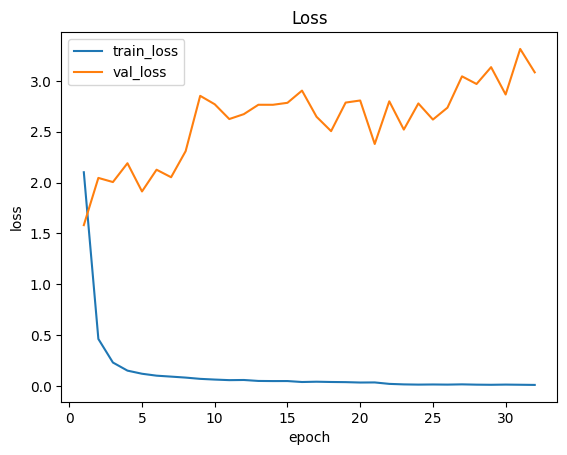

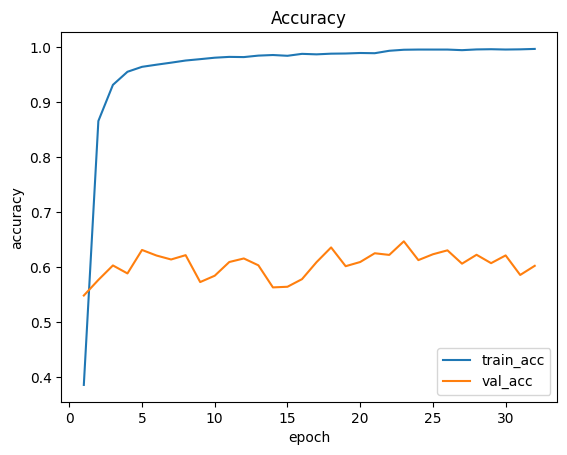

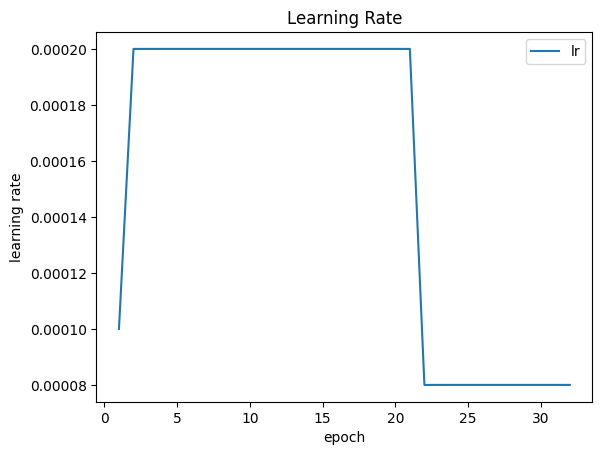

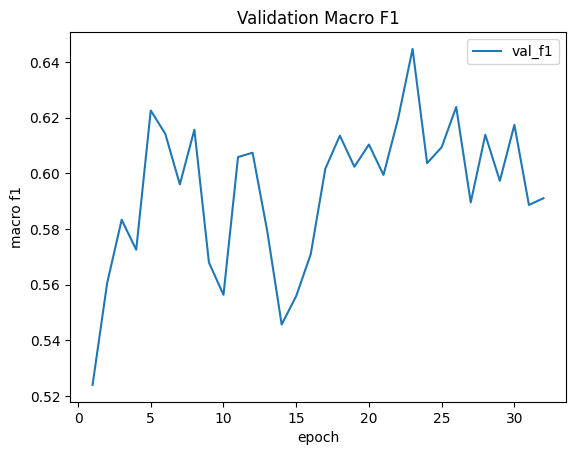

In [ ]:
if not hist.empty:
    plt.figure()
    plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
    plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Loss")
    plt.show()

    plt.figure()
    plt.plot(hist["epoch"], hist["train_acc"], label="train_acc")
    plt.plot(hist["epoch"], hist["val_acc"], label="val_acc")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title("Accuracy")
    plt.show()

    plt.figure()
    plt.plot(hist["epoch"], hist["lr"], label="lr")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("learning rate")
    plt.title("Learning Rate")
    plt.show()

if "val_f1" in hist.columns:
    plt.figure()
    plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("macro f1")
    plt.title("Validation Macro F1")
    plt.show()


## 11) Best-model evaluation

/tmp/ipykernel_1399/1204013292.py:64: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Trainable params: 2,758,007 / 3,979,719


val eval: 100%|██████████| 136/136 [00:06<00:00, 20.32it/s]


Accuracy: 0.6472081218274112
Macro F1: 0.6447207629275614

Classification report:

                          precision    recall  f1-score   support

           C1_Drive_Safe     0.3569    0.5625    0.4367       224
                C2_Sleep     0.7059    0.0777    0.1399       309
              C3_Yawning     0.8874    0.7322    0.8024       183
            C4_Talk_Left     0.8959    0.7586    0.8216       261
           C5_Talk_Right     0.9891    0.4194    0.5890       217
            C6_Text_Left     0.4130    0.6552    0.5067       145
           C7_Text_Right     0.6628    0.2511    0.3642       227
              C8_Make_Up     0.4288    0.8657    0.5735       268
            C9_Look_Left     0.8698    0.7727    0.8184       242
          C10_Look_Right     0.4792    0.8042    0.6005       143
             C11_Look_Up     0.8944    0.9863    0.9381       146
           C12_Look_Down     0.4684    0.8030    0.5917       203
          C13_Smoke_Left     0.7761    0.8171    0.7960   

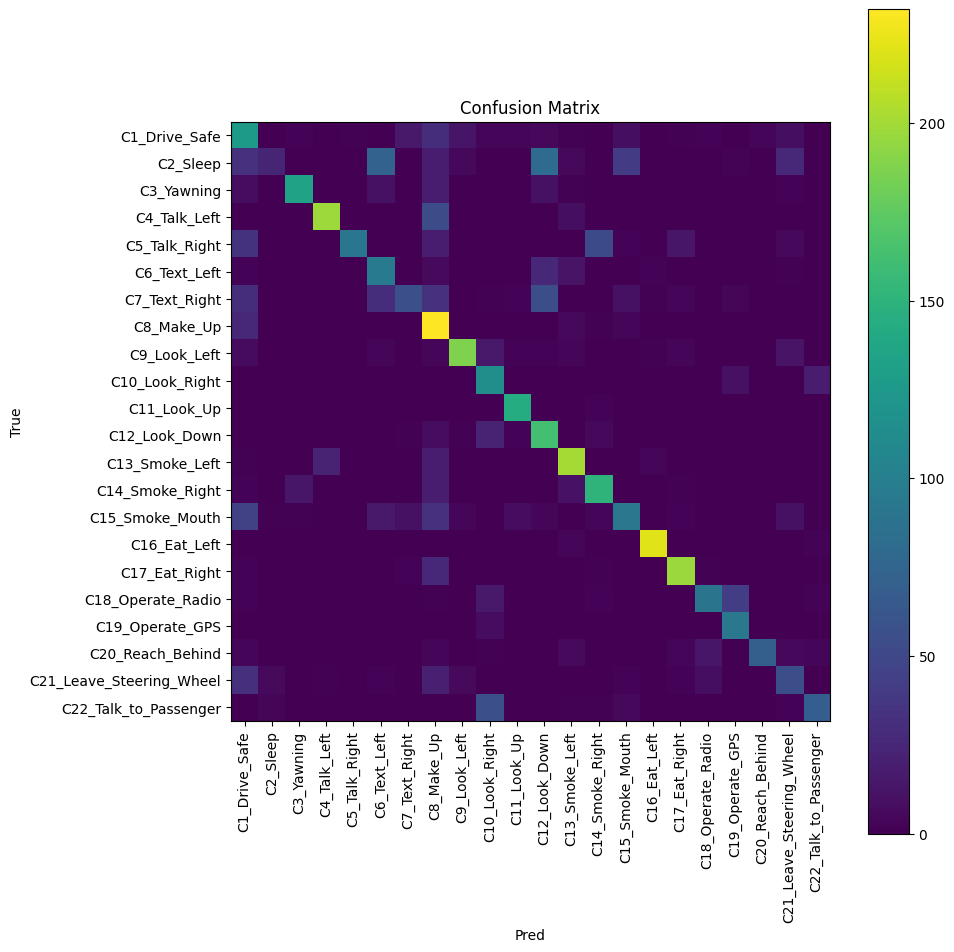

In [ ]:
best_model = build_model(NUM_CLASSES, device)

state_dict = torch.load(best_path, map_location=device)
best_model.load_state_dict(state_dict)
best_model = best_model.to(device).eval()

y_true_all, y_pred_all = [], []
with torch.no_grad():
    for batch in tqdm(val_loader, desc="val eval"):
        (images, face_points, left_points, right_points, face_valid, left_valid, right_valid), labels = batch

        images = images.to(device, non_blocking=True)
        face_points = face_points.to(device, non_blocking=True)
        left_points = left_points.to(device, non_blocking=True)
        right_points = right_points.to(device, non_blocking=True)
        face_valid = face_valid.to(device, non_blocking=True)
        left_valid = left_valid.to(device, non_blocking=True)
        right_valid = right_valid.to(device, non_blocking=True)

        logits = best_model(images, face_points, left_points, right_points, face_valid, left_valid, right_valid)
        preds = logits.argmax(1).cpu().numpy()
        y_pred_all.append(preds)
        y_true_all.append(labels.numpy())

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

print("Accuracy:", accuracy_score(y_true_all, y_pred_all))
print("Macro F1:", f1_score(y_true_all, y_pred_all, average="macro"))
print("\nClassification report:\n")
print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(10, 10))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=90)
plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
plt.xlabel("Pred")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()


## 12) Quick inference preview

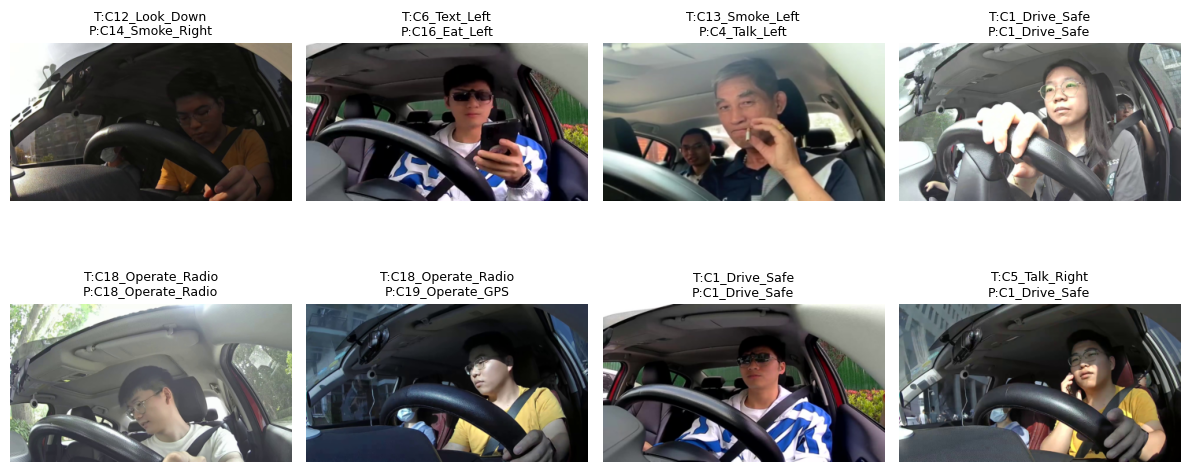

In [ ]:
def denorm(x, mean, std):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    return (x * std_t) + mean_t

best_model.eval()
sample_count = min(8, len(val_ds))
sample_idx = np.random.choice(len(val_ds), size=sample_count, replace=False)
samples = [val_ds[i] for i in sample_idx]

xb = torch.stack([s[0][0] for s in samples]).to(device)
face_b = torch.stack([s[0][1] for s in samples]).to(device)
left_b = torch.stack([s[0][2] for s in samples]).to(device)
right_b = torch.stack([s[0][3] for s in samples]).to(device)
face_valid_b = torch.stack([s[0][4] for s in samples]).to(device)
left_valid_b = torch.stack([s[0][5] for s in samples]).to(device)
right_valid_b = torch.stack([s[0][6] for s in samples]).to(device)
yb = np.array([s[1] for s in samples])

with torch.no_grad():
    logits = best_model(xb, face_b, left_b, right_b, face_valid_b, left_valid_b, right_valid_b)
    probs = torch.softmax(logits, dim=1)
    pred = probs.argmax(1).cpu().numpy()

plt.figure(figsize=(12, 6))
for i in range(sample_count):
    ax = plt.subplot(2, math.ceil(sample_count / 2), i + 1)
    img = denorm(samples[i][0][0].cpu(), mean, std).clamp(0, 1)
    ax.imshow(img.permute(1, 2, 0))
    ax.axis("off")
    ax.set_title(f"T:{CLASS_NAMES[yb[i]]}\nP:{CLASS_NAMES[pred[i]]}", fontsize=9)
plt.tight_layout()
plt.show()
